In [1]:
import math

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import rasterio

In [2]:
multiband_path = "Cw_PR_Rainbow_SiteA/MS_2022_05_26/Cw_PR_Rainbow_plotA_2022_05_26_MS_Calibrated_p28_bestPanel.tif"

with rasterio.open(multiband_path) as src:
    bands = src.read()
    nodata_value = src.nodata
    coordinate_system = src.crs
    bounds = src.bounds

print("Dimensions (bandes, hauteur, largeur):", bands.shape)
print("Valeur NoData :", nodata_value)

Dimensions (bandes, hauteur, largeur): (10, 5507, 7023)
Valeur NoData : -32767.0


In [3]:
bands_cleaned = bands.astype(float)
bands_cleaned[bands_cleaned == nodata_value] = 0.0

for band in range(bands.shape[0]):
    print(bands_cleaned[band].min(), bands_cleaned[band].max())

bands = bands_cleaned

0.0 0.14196796715259552
0.0 0.1508479118347168
0.0 0.2285463809967041
0.0 0.2509499788284302
0.0 0.2245853692293167
0.0 0.18037910759449005
0.0 0.3137302100658417
0.0 0.4109397232532501
0.0 0.675589919090271
0.0 0.6687458753585815


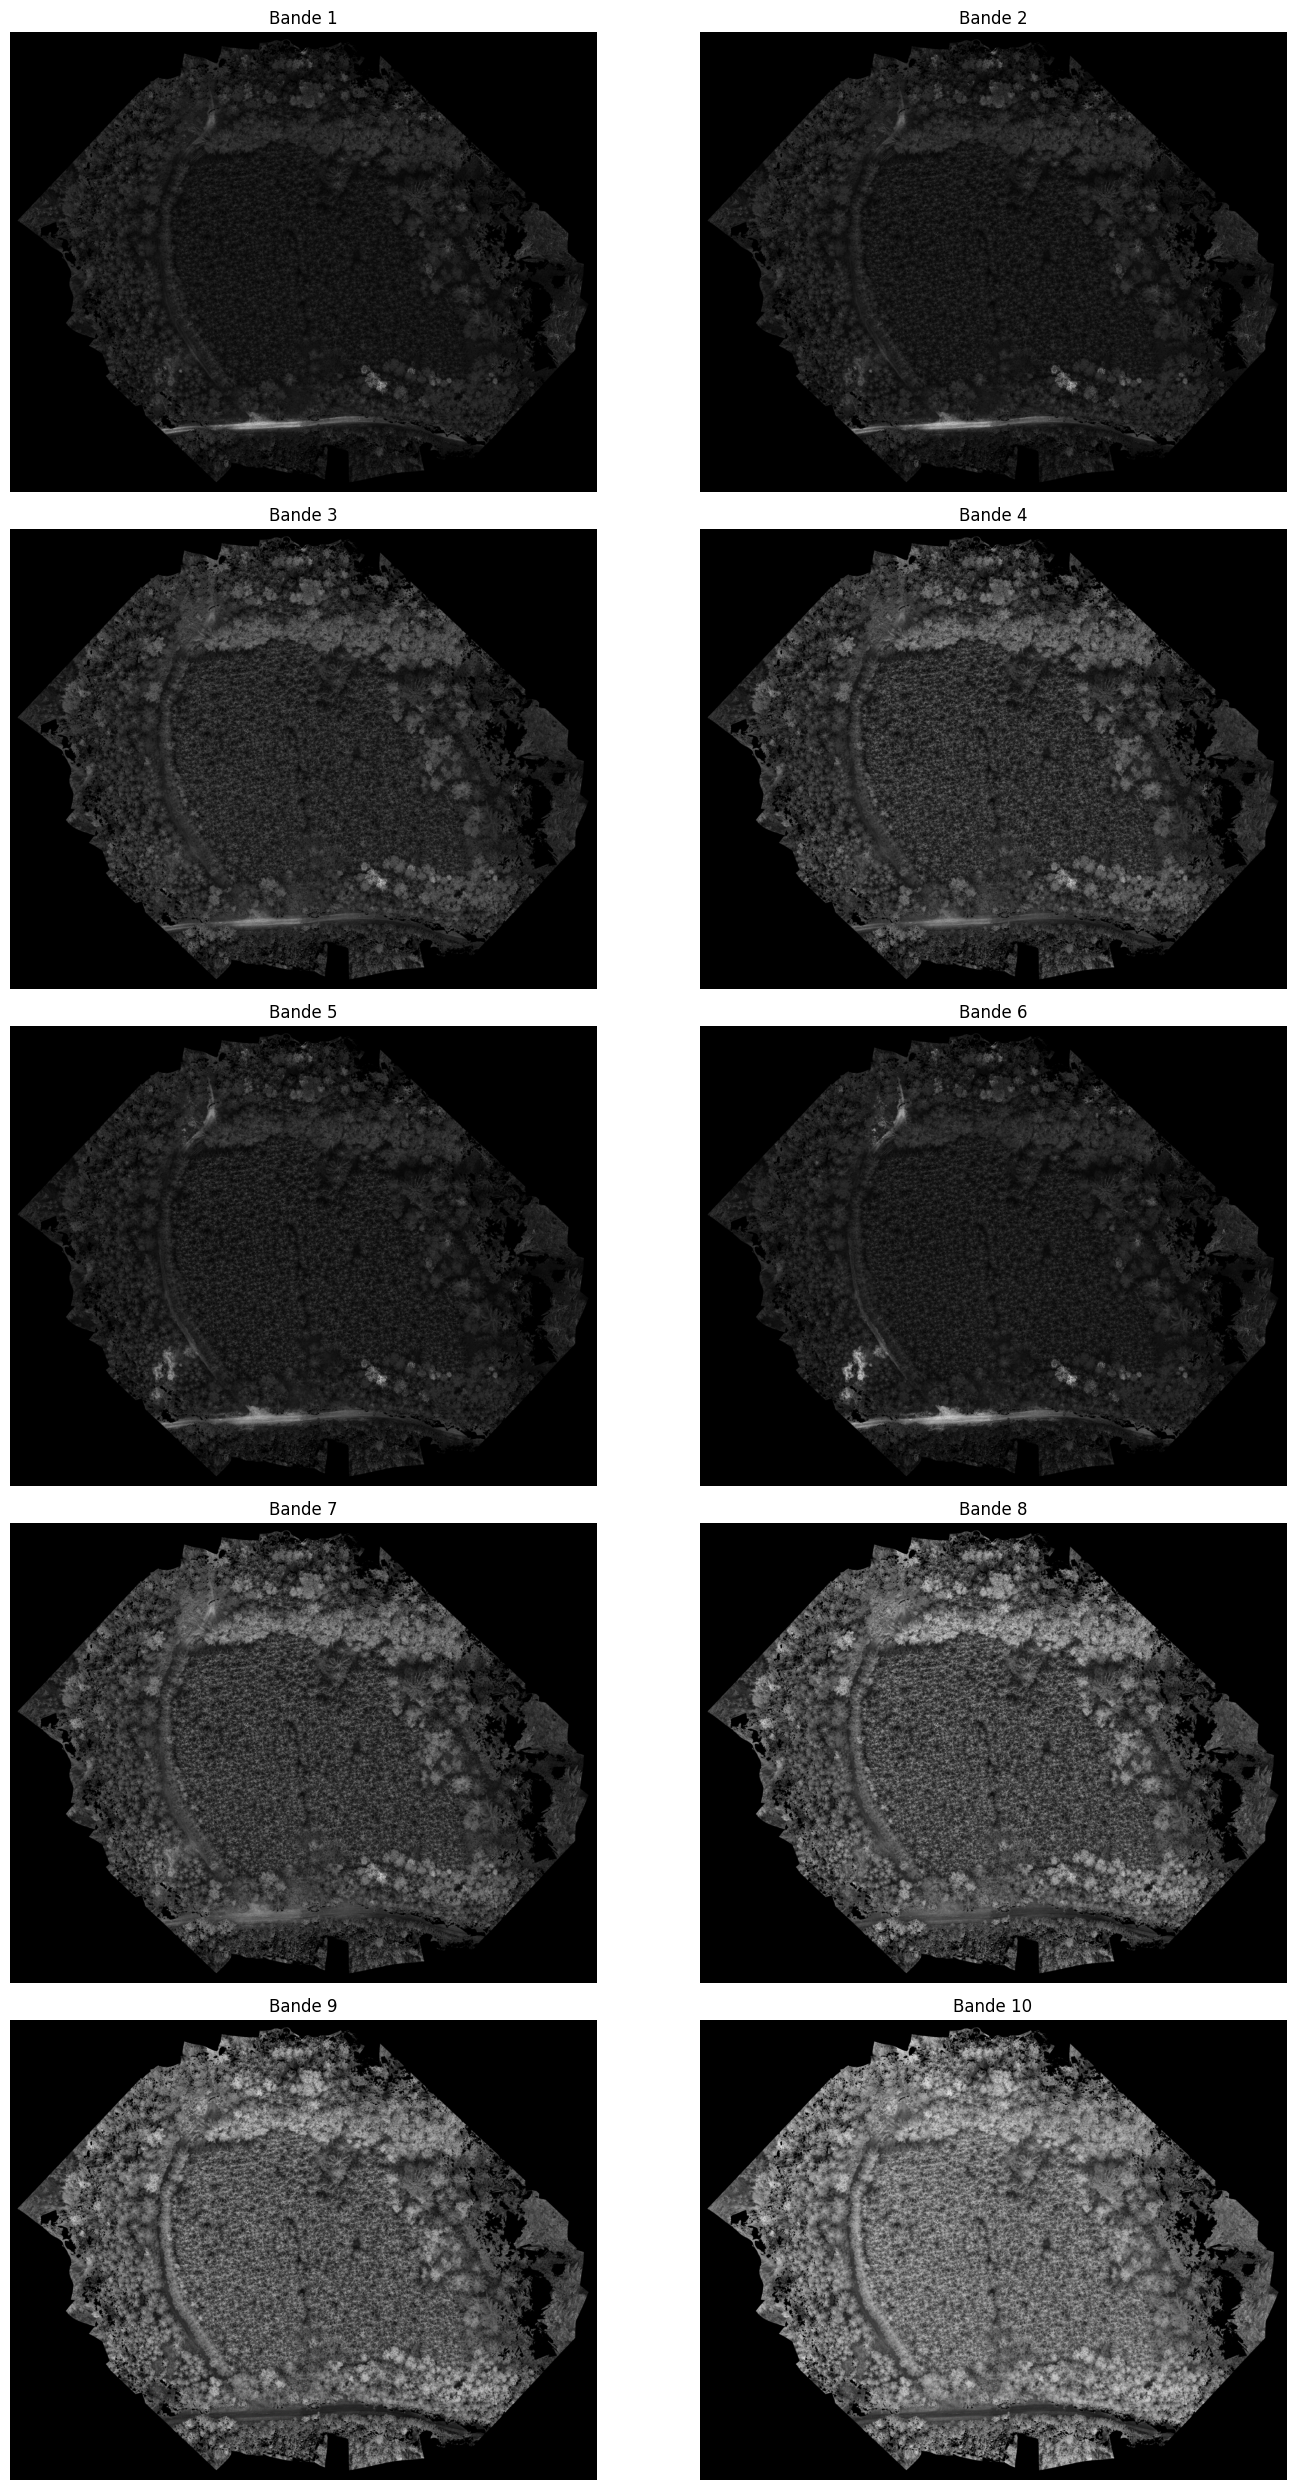

In [4]:
band_count = bands.shape[0]

rows = math.ceil(band_count / 2)

fig, axes = plt.subplots(rows, 2, figsize=(15, rows * 5))

axes = axes.flatten()

for i in range(band_count):
    ax = axes[i]
    ax.imshow(bands[i], cmap='gray')
    ax.set_title(f"Bande {i + 1}")
    ax.axis('off')

for j in range(band_count, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

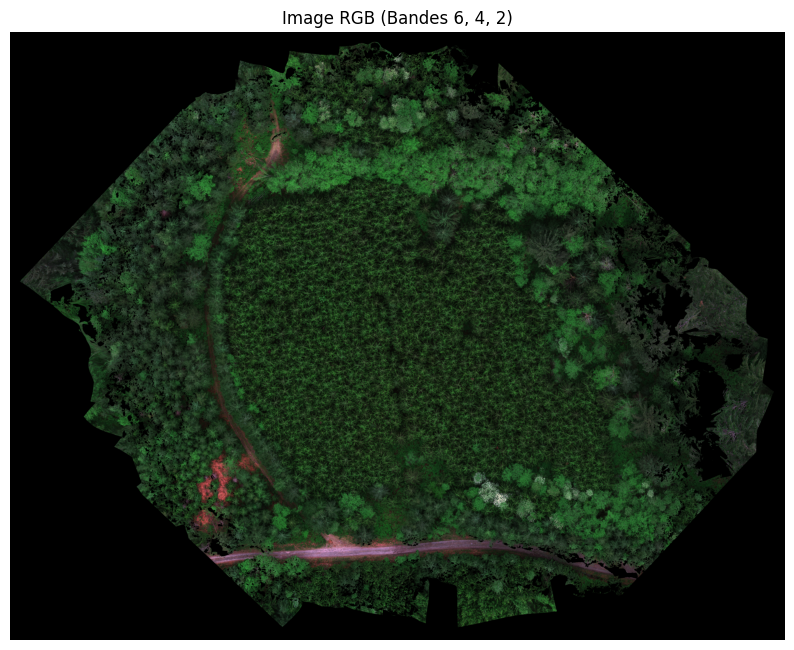

In [5]:
red = bands[5]
green = bands[3]
blue = bands[1]

red_norm = red / red.max()
green_norm = green / green.max()
blue_norm = blue / blue.max()

rgb_image = np.dstack((red_norm, green_norm, blue_norm))

plt.figure(figsize=(10, 10))
plt.imshow(rgb_image)
plt.title("Image RGB (Bandes 6, 4, 2)")
plt.axis("off")
plt.show()

In [6]:
shapefile_path = "Cw_PR_Rainbow_SiteA/Crown_IR/Edited_CHM__06_masked_RGB_H20T_thres45percent_2022_06_07_NAfilledminw3_medw3_gauss_sig_01w3_z75_crowns_2_AbsIncluded_ND.shp"

shapes = gpd.read_file(shapefile_path)

if shapes.crs != coordinate_system:
    shapes = shapes.to_crs(coordinate_system)

geometries = shapes.geometry

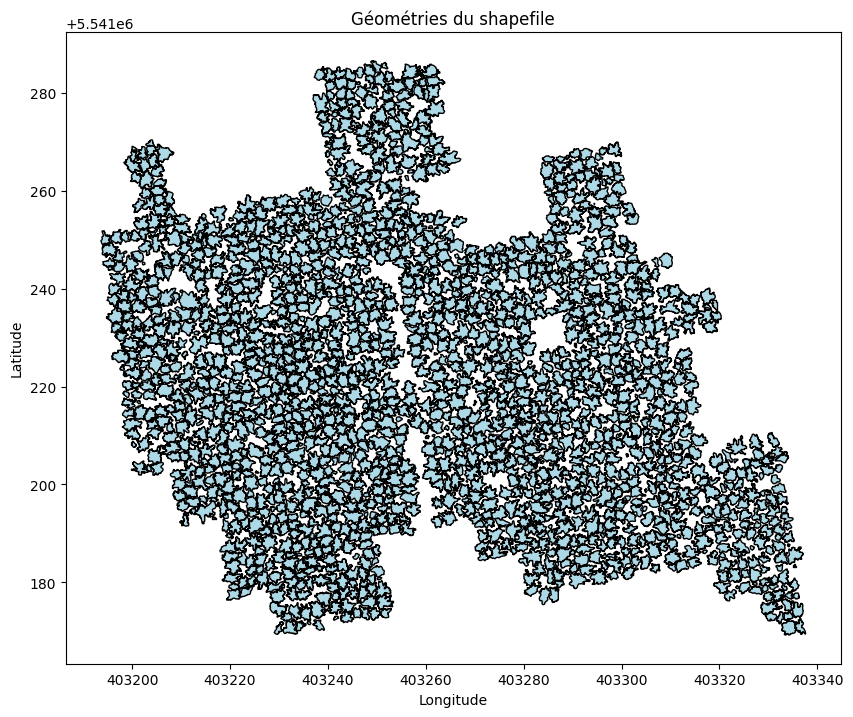

In [7]:
shapes.plot(color="lightblue", edgecolor="black", figsize=(10, 10))

plt.title("Géométries du shapefile")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

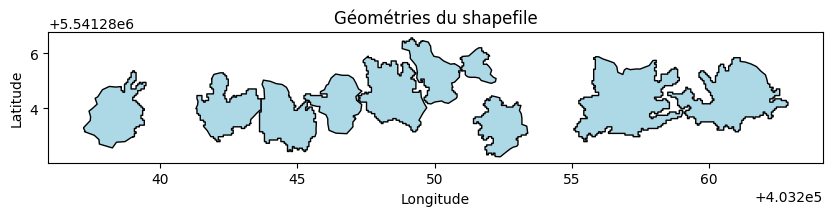

In [8]:
shapes.head(10).plot(color="lightblue", edgecolor="black", figsize=(10, 10))

plt.title("Géométries du shapefile")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

In [9]:
# .tif
print("Raster")
print("CRS: ", coordinate_system.to_wkt())
print("Limites:", bounds)

print()

# .shp
print("Shapefile")
print("CRS: ", shapes.crs)
print("Limites du shapefile :", shapes.total_bounds)

Raster
CRS:  PROJCS["NAD83 / UTM zone 10N",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101004,AUTHORITY["EPSG","7019"]],TOWGS84[0,0,0,0,0,0,0],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4269"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-123],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","26910"]]
Limites: BoundingBox(left=403109.65716793854, bottom=5541111.584131965, right=403406.67739543854, top=5541344.488929465)

Shapefile
CRS:  PROJCS["NAD83 / UTM zone 10N",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101004,AUTHORITY["EPSG","7019"]],TOWGS84[0,0,0,0,0,0,0],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0],UNIT["degr

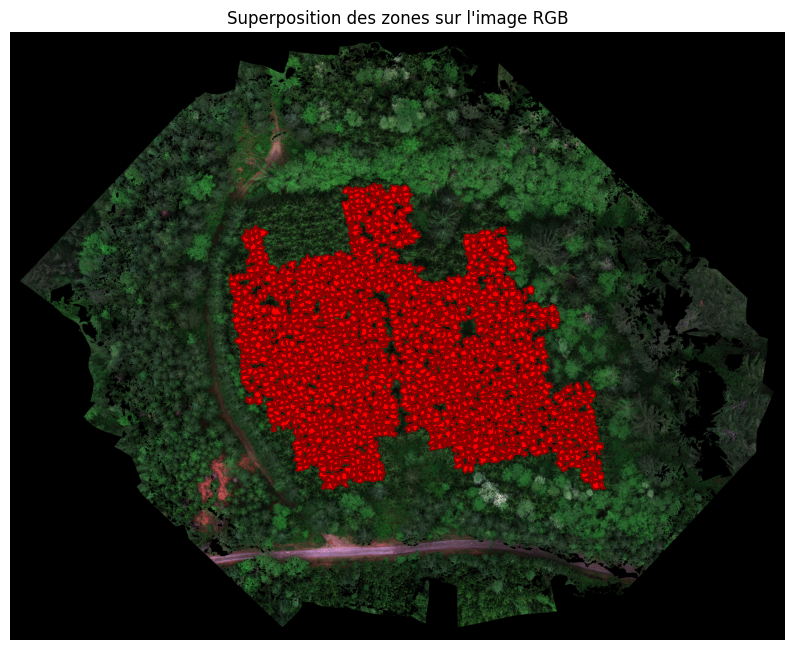

In [10]:
fig, ax = plt.subplots(figsize=(10, 10))

ax.imshow(rgb_image, extent=(bounds.left, bounds.right, bounds.bottom, bounds.top), origin="upper")

shapes.plot(ax=ax, facecolor="red", edgecolor="darkred", linewidth=1)

plt.title("Superposition des zones sur l'image RGB")
plt.axis("off")
plt.show()